# 10 - Final Forecasting 


## Analytical Objectives 
- Load the final model evaluation results. 
- Identify the selected forecasting model. 
- Load the trained final model. 
- Prepare the Walmart test dataset using the same feature engineering process. 
- Generate future weekly sales forecasts. 
- Create store-level forecasts. 
- Create department-level forecasts. 
- Analyze the forecasted sales distribution. 
- Identify stores with the highest expected sales. 
- Identify departments with the highest expected sales. 
- Save the final forecast dataset. 
- Produce business-ready forecasting insights.

 ## Expected Outcome 
 
 By the end of this notebook, we will have: 

 - A final selected forecasting model. 
 - Future weekly sales predictions. 
 - Store-level sales forecasts. 
 - Department-level sales forecasts. 
 - A final forecast dataset for business use. 
 - Business insights that can support inventory and staffing decisions.

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

#### Load Final Model Evaluation

In [2]:
final_evaluation = pd.read_csv(
    "../reports/figures/final_model_evaluation.csv"
)

final_evaluation

,Selected_Model,MAE,RMSE,MAPE,Baseline_MAE,MAE_Improvement_Percent
0,XGBoost,1200.494662,2602.177309,1.813349e+16,1540.862076,22.089415


In [3]:
#Check the selected model:

selected_model = final_evaluation.loc[
    0,
    "Selected_Model"
]

print("Selected Model:", selected_model)

Selected Model: XGBoost


#### Load the Selected Model

In [4]:
if selected_model == "XGBoost":

    final_model = joblib.load(
        "../models/xgboost_model.pkl"
    )

elif selected_model == "LightGBM":

    final_model = joblib.load(
        "../models/lightgbm_model.pkl"
    )

print("Model loaded:", selected_model)

Model loaded: XGBoost


In [5]:
final_model

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


#### Load Test Feature Dataset

In [6]:
test_features = pd.read_csv(
    "../data/processed/test_feature_engineered.csv"
)

test_features["Date"] = pd.to_datetime(
    test_features["Date"]
)

print("Test Shape:", test_features.shape)

test_features.head()

Test Shape: (468577, 60)


,Store,Dept,Date,IsHoliday,Store.1,Dept.1,Year,Quarter,Month,Week,...,Dept_Sales_Rank,Dept_Sales_Contribution,Month_Sin,Month_Cos,Week_Sin,Week_Cos,Quarter_Sin,Quarter_Cos,DayOfWeek_Sin,DayOfWeek_Cos
0,1,1,2012-11-02,False,1,1,2012,4,11,44,...,21.0,0.016905,-0.5,0.866025,-0.822984,0.568065,-2.449294e-16,1.0,-0.433884,-0.900969
1,1,1,2012-11-02,False,1,1,2012,4,11,44,...,21.0,0.016905,-0.5,0.866025,-0.822984,0.568065,-2.449294e-16,1.0,-0.433884,-0.900969
2,1,1,2012-11-02,False,1,1,2012,4,11,44,...,21.0,0.016905,-0.5,0.866025,-0.822984,0.568065,-2.449294e-16,1.0,-0.433884,-0.900969
3,1,1,2012-11-02,False,1,1,2012,4,11,44,...,21.0,0.016905,-0.5,0.866025,-0.822984,0.568065,-2.449294e-16,1.0,-0.433884,-0.900969
4,1,1,2012-11-02,False,1,1,2012,4,11,44,...,21.0,0.016905,-0.5,0.866025,-0.822984,0.568065,-2.449294e-16,1.0,-0.433884,-0.900969


#### Check Columns

In [7]:
test_features.columns.tolist()

['Store',
 'Dept',
 'Date',
 'IsHoliday',
 'Store.1',
 'Dept.1',
 'Year',
 'Quarter',
 'Month',
 'Week',
 'Day',
 'DayOfWeek',
 'IsWeekend',
 'Holiday_Flag',
 'Previous_Holiday',
 'Next_Holiday',
 'Near_Holiday',
 'Temperature',
 'Fuel_Price',
 'CPI',
 'Unemployment',
 'Lag_1',
 'Lag_2',
 'Lag_4',
 'Lag_8',
 'Lag_12',
 'Lag_52',
 'Rolling_Mean_4',
 'Rolling_Mean_8',
 'Rolling_Mean_12',
 'Rolling_Std_4',
 'Rolling_Std_8',
 'Rolling_Std_12',
 'Rolling_Min_4',
 'Rolling_Max_4',
 'Expanding_Mean',
 'Expanding_Std',
 'Expanding_Min',
 'Expanding_Max',
 'Store_Avg_Sales',
 'Store_Std_Sales',
 'Store_Min_Sales',
 'Store_Max_Sales',
 'Store_Sales_Rank',
 'Store_Type',
 'Store_Size_Relative',
 'Dept_Avg_Sales',
 'Dept_Std_Sales',
 'Dept_Min_Sales',
 'Dept_Max_Sales',
 'Dept_Sales_Rank',
 'Dept_Sales_Contribution',
 'Month_Sin',
 'Month_Cos',
 'Week_Sin',
 'Week_Cos',
 'Quarter_Sin',
 'Quarter_Cos',
 'DayOfWeek_Sin',
 'DayOfWeek_Cos']

In [8]:
test_features.isnull().sum()

Store                           0
Dept                            0
Date                            0
IsHoliday                       0
Store.1                         0
Dept.1                          0
Year                            0
Quarter                         0
Month                           0
Week                            0
Day                             0
DayOfWeek                       0
IsWeekend                       0
Holiday_Flag                    0
Previous_Holiday                0
Next_Holiday                    0
Near_Holiday                    0
Temperature                  6358
Fuel_Price                   6358
CPI                         41498
Unemployment                41498
Lag_1                      455933
Lag_2                      442852
Lag_4                      427743
Lag_8                      376524
Lag_12                     334626
Lag_52                       8417
Rolling_Mean_4                150
Rolling_Mean_8                150
Rolling_Mean_1

#### Prepare Features

In [10]:
#Select Features

feature_columns = [

    # Store / Department
    "Store",
    "Dept",

    # Calendar
    "Year",
    "Quarter",
    "Month",
    "Week",
    "Day",
    "DayOfWeek",
    "IsWeekend",

    # Holiday
    "Holiday_Flag",
    "Previous_Holiday",
    "Next_Holiday",
    "Near_Holiday",

    # External variables
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",

    # Lag features
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Lag_8",
    "Lag_12",
    "Lag_52",

    # Rolling features
    "Rolling_Mean_4",
    "Rolling_Mean_8",
    "Rolling_Mean_12",
    "Rolling_Std_4",
    "Rolling_Std_8",
    "Rolling_Std_12",
    "Rolling_Min_4",
    "Rolling_Max_4",

    # Expanding features
    "Expanding_Mean",
    "Expanding_Std",
    "Expanding_Min",
    "Expanding_Max",

    # Store features
    "Store_Avg_Sales",
    "Store_Std_Sales",
    "Store_Min_Sales",
    "Store_Max_Sales",
    "Store_Sales_Rank",
    "Store_Type",
    "Store_Size_Relative",

    # Department features
    "Dept_Avg_Sales",
    "Dept_Std_Sales",
    "Dept_Min_Sales",
    "Dept_Max_Sales",
    "Dept_Sales_Rank",
    "Dept_Sales_Contribution",

    # Cyclical features
    "Month_Sin",
    "Month_Cos",
    "Week_Sin",
    "Week_Cos",
    "Quarter_Sin",
    "Quarter_Cos",
    "DayOfWeek_Sin",
    "DayOfWeek_Cos"
]

In [11]:
feature_columns

['Store',
 'Dept',
 'Year',
 'Quarter',
 'Month',
 'Week',
 'Day',
 'DayOfWeek',
 'IsWeekend',
 'Holiday_Flag',
 'Previous_Holiday',
 'Next_Holiday',
 'Near_Holiday',
 'Temperature',
 'Fuel_Price',
 'CPI',
 'Unemployment',
 'Lag_1',
 'Lag_2',
 'Lag_4',
 'Lag_8',
 'Lag_12',
 'Lag_52',
 'Rolling_Mean_4',
 'Rolling_Mean_8',
 'Rolling_Mean_12',
 'Rolling_Std_4',
 'Rolling_Std_8',
 'Rolling_Std_12',
 'Rolling_Min_4',
 'Rolling_Max_4',
 'Expanding_Mean',
 'Expanding_Std',
 'Expanding_Min',
 'Expanding_Max',
 'Store_Avg_Sales',
 'Store_Std_Sales',
 'Store_Min_Sales',
 'Store_Max_Sales',
 'Store_Sales_Rank',
 'Store_Type',
 'Store_Size_Relative',
 'Dept_Avg_Sales',
 'Dept_Std_Sales',
 'Dept_Min_Sales',
 'Dept_Max_Sales',
 'Dept_Sales_Rank',
 'Dept_Sales_Contribution',
 'Month_Sin',
 'Month_Cos',
 'Week_Sin',
 'Week_Cos',
 'Quarter_Sin',
 'Quarter_Cos',
 'DayOfWeek_Sin',
 'DayOfWeek_Cos']

In [12]:
X_final = test_features[feature_columns]

print("Final Feature Shape:", X_final.shape)

Final Feature Shape: (468577, 56)


In [13]:
X_final.head()

,Store,Dept,Year,Quarter,Month,Week,Day,DayOfWeek,IsWeekend,Holiday_Flag,...,Dept_Sales_Rank,Dept_Sales_Contribution,Month_Sin,Month_Cos,Week_Sin,Week_Cos,Quarter_Sin,Quarter_Cos,DayOfWeek_Sin,DayOfWeek_Cos
0,1,1,2012,4,11,44,2,4,0,0,...,21.0,0.016905,-0.5,0.866025,-0.822984,0.568065,-2.449294e-16,1.0,-0.433884,-0.900969
1,1,1,2012,4,11,44,2,4,0,0,...,21.0,0.016905,-0.5,0.866025,-0.822984,0.568065,-2.449294e-16,1.0,-0.433884,-0.900969
2,1,1,2012,4,11,44,2,4,0,0,...,21.0,0.016905,-0.5,0.866025,-0.822984,0.568065,-2.449294e-16,1.0,-0.433884,-0.900969
3,1,1,2012,4,11,44,2,4,0,0,...,21.0,0.016905,-0.5,0.866025,-0.822984,0.568065,-2.449294e-16,1.0,-0.433884,-0.900969
4,1,1,2012,4,11,44,2,4,0,0,...,21.0,0.016905,-0.5,0.866025,-0.822984,0.568065,-2.449294e-16,1.0,-0.433884,-0.900969


#### Generate Final Forecast

In [14]:
final_predictions = final_model.predict(
    X_final
)

In [15]:
final_predictions[:10]

array([36479.902, 36369.63 , 36420.754, 36874.617, 37474.945, 57594.01 ,
       56067.34 , 55756.516, 68267.12 , 71454.23 ], dtype=float32)

In [16]:
#Check the number of predictions:

print(
    "Number of Predictions:",
    len(final_predictions)
)

Number of Predictions: 468577


In [17]:
print(
    "Number of Test Rows:",
    len(test_features)
)

Number of Test Rows: 468577


#### Create Final Forecast Dataset

In [18]:
final_forecast = test_features[
    [
        "Date",
        "Store",
        "Dept",
        "IsHoliday"
    ]
].copy()

final_forecast["Forecasted_Weekly_Sales"] = (
    final_predictions
)

final_forecast.head()

,Date,Store,Dept,IsHoliday,Forecasted_Weekly_Sales
0,2012-11-02,1,1,False,36479.902344
1,2012-11-02,1,1,False,36369.628906
2,2012-11-02,1,1,False,36420.753906
3,2012-11-02,1,1,False,36874.617188
4,2012-11-02,1,1,False,37474.945312


#### Check Final Forecast

In [19]:
final_forecast.info()

<class 'pandas.DataFrame'>
RangeIndex: 468577 entries, 0 to 468576
Data columns (total 5 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Date                     468577 non-null  datetime64[us]
 1   Store                    468577 non-null  int64         
 2   Dept                     468577 non-null  int64         
 3   IsHoliday                468577 non-null  bool          
 4   Forecasted_Weekly_Sales  468577 non-null  float32       
dtypes: bool(1), datetime64[us](1), float32(1), int64(2)
memory usage: 13.0 MB


In [20]:
final_forecast[
    "Forecasted_Weekly_Sales"
].isnull().sum()

np.int64(0)

In [21]:
final_forecast[
    "Forecasted_Weekly_Sales"
].describe()

count    468577.000000
mean      84018.679688
std       18992.201172
min       -1826.994019
25%       77649.906250
50%       82965.585938
75%       90200.828125
max      442352.187500
Name: Forecasted_Weekly_Sales, dtype: float64

#### Total Forecasted Sales

In [22]:
total_forecast = (
    final_forecast[
        "Forecasted_Weekly_Sales"
    ].sum()
)

print(
    f"Total Forecasted Sales: "
    f"${total_forecast:,.2f}"
)

Total Forecasted Sales: $39,369,220,096.00


#### Weekly Forecast

In [23]:
weekly_forecast = (
    final_forecast
    .groupby("Date")
    .agg(
        Forecasted_Sales=(
            "Forecasted_Weekly_Sales",
            "sum"
        )
    )
    .reset_index()
)

weekly_forecast.head()

,Date,Forecasted_Sales
0,2012-11-02,2.277333e+08
1,2012-11-09,7.129565e+08
2,2012-11-16,9.344203e+08
3,2012-11-23,2.661309e+08
4,2012-11-30,1.186886e+09


#### Weekly Forecast Trend

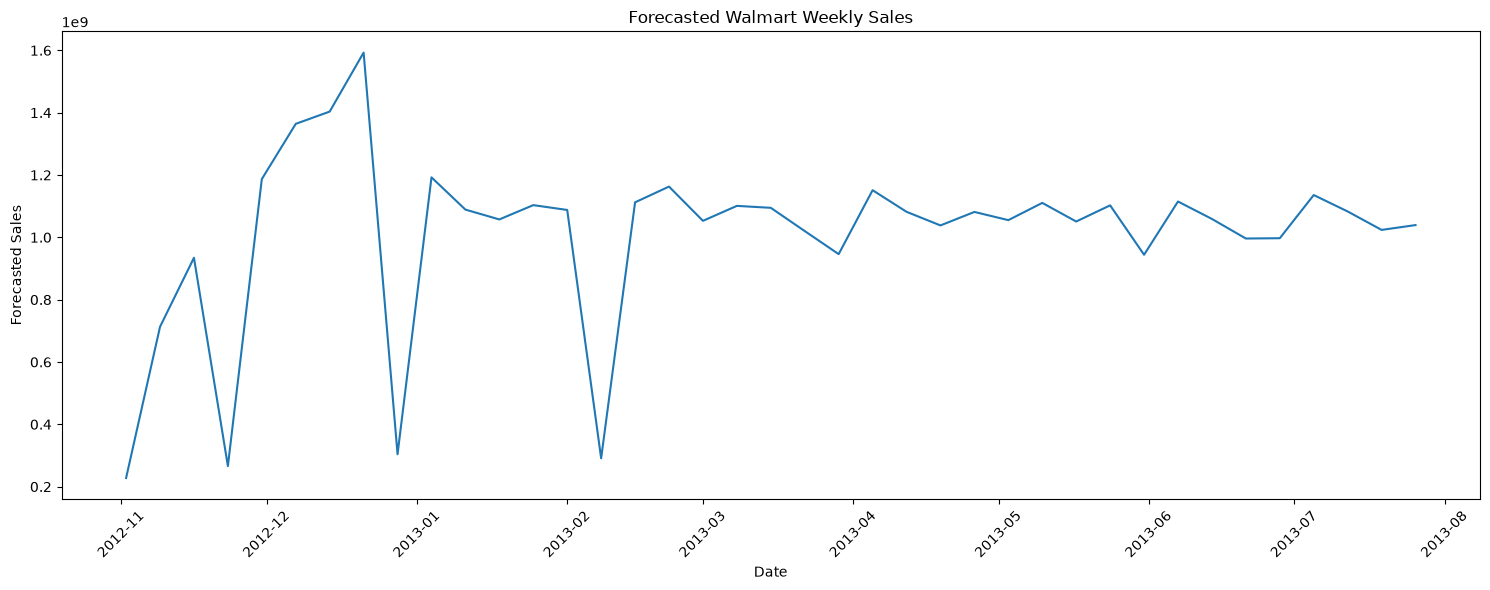

In [24]:
plt.figure(figsize=(15, 6))

plt.plot(
    weekly_forecast["Date"],
    weekly_forecast["Forecasted_Sales"]
)

plt.title(
    "Forecasted Walmart Weekly Sales"
)

plt.xlabel("Date")
plt.ylabel("Forecasted Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

#### Forecast by Store

In [25]:
store_forecast = (
    final_forecast
    .groupby("Store")
    .agg(
        Forecasted_Sales=(
            "Forecasted_Weekly_Sales",
            "sum"
        )
    )
    .reset_index()
    .sort_values(
        "Forecasted_Sales",
        ascending=False
    )
)

store_forecast.head(10)

,Store,Forecasted_Sales
9,10,1.091683e+09
3,4,1.086722e+09
12,13,1.068960e+09
1,2,1.051232e+09
0,1,1.018567e+09
19,20,1.014911e+09
13,14,1.014855e+09
26,27,9.922352e+08
5,6,9.881942e+08
38,39,9.744130e+08


#### Top 10 Stores

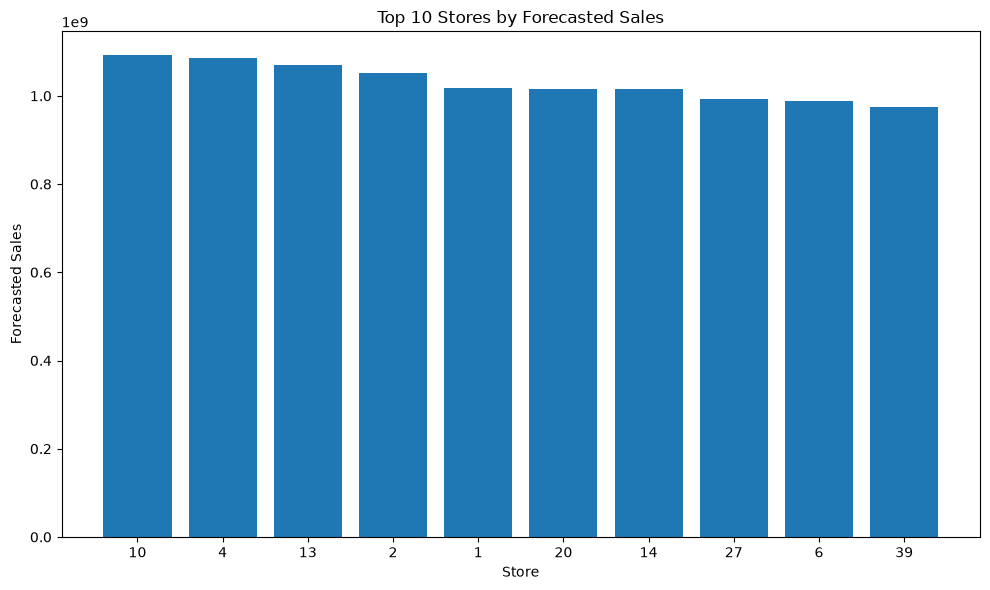

In [26]:
top_stores = store_forecast.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_stores["Store"].astype(str),
    top_stores["Forecasted_Sales"]
)

plt.title(
    "Top 10 Stores by Forecasted Sales"
)

plt.xlabel("Store")
plt.ylabel("Forecasted Sales")

plt.tight_layout()

plt.show()

#### Forecast by Department

In [27]:
department_forecast = (
    final_forecast
    .groupby("Dept")
    .agg(
        Forecasted_Sales=(
            "Forecasted_Weekly_Sales",
            "sum"
        )
    )
    .reset_index()
    .sort_values(
        "Forecasted_Sales",
        ascending=False
    )
)

department_forecast.head(10)

,Dept,Forecasted_Sales
73,92,819244480.0
76,95,770737472.0
36,38,695413632.0
71,90,680454720.0
38,40,657484992.0
1,2,654125568.0
60,72,644846080.0
72,91,641720384.0
12,13,630687872.0
7,8,628802880.0


#### Top 10 Departments

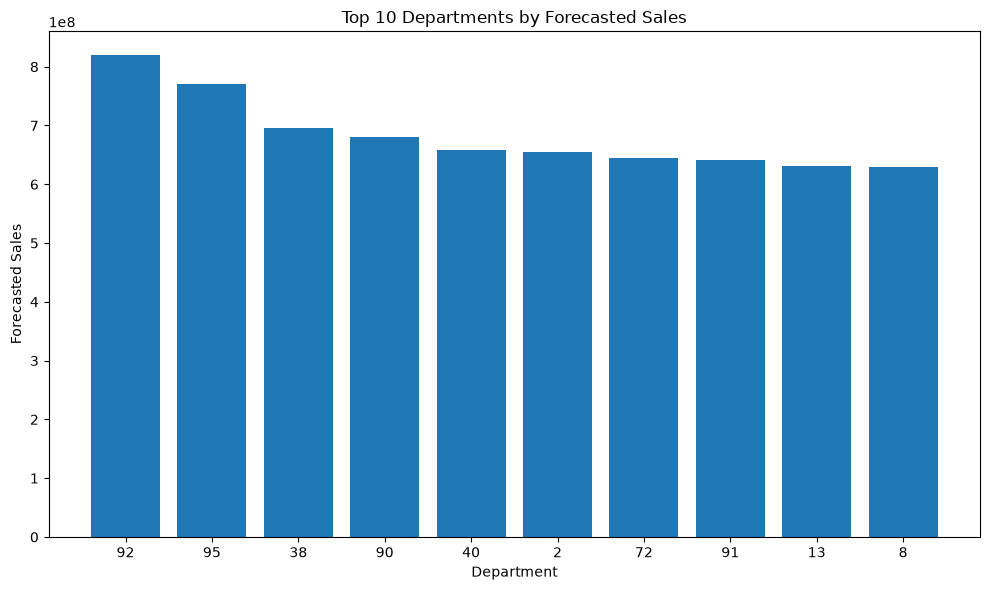

In [28]:
top_departments = department_forecast.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_departments["Dept"].astype(str),
    top_departments["Forecasted_Sales"]
)

plt.title(
    "Top 10 Departments by Forecasted Sales"
)

plt.xlabel("Department")
plt.ylabel("Forecasted Sales")

plt.tight_layout()

plt.show()

#### Holiday Forecast

In [29]:
holiday_forecast = (
    final_forecast
    .groupby("IsHoliday")
    .agg(
        Forecasted_Sales=(
            "Forecasted_Weekly_Sales",
            "sum"
        ),
        Average_Forecast=(
            "Forecasted_Weekly_Sales",
            "mean"
        )
    )
    .reset_index()
)

holiday_forecast

,IsHoliday,Forecasted_Sales,Average_Forecast
0,False,3.850809e+10,83852.320312
1,True,8.611248e+08,92197.515625


#### Save Final Forecast

In [30]:
os.makedirs(
    "../data/processed",
    exist_ok=True
)

os.makedirs(
    "../reports",
    exist_ok=True
)

In [31]:
final_forecast.to_csv(
    "../data/processed/final_forecast.csv",
    index=False
)

#### Save Weekly Forecast

In [32]:
weekly_forecast.to_csv(
    "../reports/final_weekly_forecast.csv",
    index=False
)

#### Save Store Forecast

In [33]:
store_forecast.to_csv(
    "../reports/final_store_forecast.csv",
    index=False
)

#### Save Department Forecast

In [34]:
department_forecast.to_csv(
    "../reports/final_department_forecast.csv",
    index=False
)

#### Create Business Summary

In [35]:
business_summary = pd.DataFrame({
    "Selected_Model": [
        selected_model
    ],
    "Total_Forecasted_Sales": [
        total_forecast
    ],
    "Top_Store": [
        store_forecast.iloc[0]["Store"]
    ],
    "Top_Store_Forecast": [
        store_forecast.iloc[0]["Forecasted_Sales"]
    ],
    "Top_Department": [
        department_forecast.iloc[0]["Dept"]
    ],
    "Top_Department_Forecast": [
        department_forecast.iloc[0]["Forecasted_Sales"]
    ]
})

business_summary

,Selected_Model,Total_Forecasted_Sales,Top_Store,Top_Store_Forecast,Top_Department,Top_Department_Forecast
0,XGBoost,3.936922e+10,10.0,1.091683e+09,92.0,819244480.0


#### Save Business Summary

In [36]:
business_summary.to_csv(
    "../reports/final_business_summary.csv",
    index=False
)

#### Final Verification

In [37]:
print(
    "Final Forecast Shape:",
    final_forecast.shape
)

print(
    "Weekly Forecast Shape:",
    weekly_forecast.shape
)

print(
    "Store Forecast Shape:",
    store_forecast.shape
)

print(
    "Department Forecast Shape:",
    department_forecast.shape
)

Final Forecast Shape: (468577, 5)
Weekly Forecast Shape: (39, 2)
Store Forecast Shape: (45, 2)
Department Forecast Shape: (81, 2)


In [38]:
final_forecast.head(10)

,Date,Store,Dept,IsHoliday,Forecasted_Weekly_Sales
0,2012-11-02,1,1,False,36479.902344
1,2012-11-02,1,1,False,36369.628906
2,2012-11-02,1,1,False,36420.753906
3,2012-11-02,1,1,False,36874.617188
4,2012-11-02,1,1,False,37474.945312
5,2012-11-09,1,1,False,57594.011719
6,2012-11-09,1,1,False,56067.339844
7,2012-11-09,1,1,False,55756.515625
8,2012-11-16,1,1,False,68267.117188
9,2012-11-16,1,1,False,71454.226562


### Key Observations

- The selected forecasting model was used to generate future Walmart weekly sales predictions.
- Forecasts were aggregated by week, store, and department.
- Store-level forecasts identify locations with the highest expected sales.
- Department-level forecasts identify departments with the highest expected demand.
- Weekly forecasts provide an overall view of expected future sales.
- Holiday forecasts provide additional information for seasonal planning.
- The final forecast datasets were saved for further business analysis.

### Executive Summary

The final forecasting model was used to generate Walmart weekly sales predictions for the test period.

The forecast was analyzed at weekly, store, department, and holiday levels. These results can support inventory planning, staffing decisions, and resource allocation.

The final forecast dataset and supporting summary files were saved in the project folders.

This completes the main Walmart Sales Forecasting workflow from data understanding through final forecasting.